# Limpieza de datos: carga, enriquecimiento, valores perdidos y atípicos

> Cómo pasar de datos en bruto a un conjunto fiable: verificar la carga, combinar fuentes, corregir errores y tratar valores perdidos y atípicos, justificando cada decisión.
>
> **Requisitos previos:** [Análisis exploratorio](01-analisis-exploratorio.ipynb) · **Relacionado:** [Transformación de datos](03-transformacion-datos.ipynb), [Muestreo y desbalanceo](04-muestreo-y-desbalanceo.ipynb)

## 1. Idea clave

Los modelos de aprendizaje automático son muy sensibles a la calidad de los datos de entrada: si entra basura, sale basura (*garbage in, garbage out*, GIGO). La **limpieza de datos** (*data cleaning*) consiste en detectar y corregir, eliminar o marcar los registros erróneos, incoherentes o incompletos antes de analizar o modelar.

En la práctica agrupa cuatro tareas:

- **Carga y verificación**: comprobar que los datos se han leído bien (filas, columnas, tipos, separadores, codificación).
- **Enriquecimiento** (integración de fuentes, *data integration*): combinar varias fuentes (`concat` para añadir filas, `merge` para añadir columnas) sin perder ni duplicar registros.
- **Valores perdidos** (*missing values*): decidir si eliminarlos o imputarlos, según *por qué* faltan.
- **Valores atípicos** (*outliers*): distinguir entre errores (corregir), valores centinela (convertir en perdidos) y valores legítimos pero extremos (conservar o tratar con métodos robustos).

Dentro del ciclo CRISP-DM es parte de la **preparación de los datos** y suele llevarse la mayor parte del tiempo de un proyecto. No hay una limpieza "correcta" universal: cada decisión depende del dominio y **debe quedar justificada y documentada**, porque cambia los resultados del análisis posterior.

## 2. Conceptos importantes

### 2.1. Tipos de variable

Antes de limpiar hay que saber **qué tipo de dato debería ser** cada columna, porque de eso depende qué errores son posibles y cómo tratarlos:

| Tipo estadístico | Subtipo | Ejemplo | Tipo en pandas |
|---|---|---|---|
| Categórica (cualitativa) | Nominal (sin orden) | puerto de embarque, sexo | `category`, `string` |
| | Ordinal (con orden) | clase del billete, nivel de estudios | `category` ordenada |
| Cuantitativa | Discreta (recuentos) | número de hermanos a bordo | `int` |
| | Continua (medidas) | edad, tarifa | `float` |

Dos trampas habituales:
- **Categóricas disfrazadas de números**: códigos como `1`/`0` (sí/no) o `pclass = 1, 2, 3` se leen como `int`, pero calcular su media no tiene sentido.
- **Números leídos como texto**: una coma decimal (`"3,4"`), un símbolo (`"12 €"`) o un código especial en la columna hacen que toda ella se lea como `object`/`string`.

### 2.2. Por qué faltan los datos: MCAR, MAR y MNAR

Antes de imputar hay que preguntarse **por qué** falta cada valor. La clasificación clásica de Rubin (1976) distingue tres mecanismos:

| Mecanismo | Significado | Ejemplo | Consecuencia |
|---|---|---|---|
| **MCAR** (*missing completely at random*) | La ausencia no depende de nada | un sensor falla al azar | Eliminar filas no sesga (solo reduce la muestra) |
| **MAR** (*missing at random*) | Depende de otras variables **observadas** | en el Titanic falta la cubierta (`deck`) mucho más en 3.ª clase | Imputar usando esas variables (por grupo, kNN, modelos) |
| **MNAR** (*missing not at random*) | Depende del **propio valor** que falta | quien cobra mucho no declara su salario | Ningún método lo corrige del todo; hay que usar el conocimiento del dominio |

Hay un cuarto caso muy frecuente en la práctica: el **vacío estructural o legítimo**. El campo no aplica, o "vacío" significa "cero". Por ejemplo, en un registro de accidentes la columna *número de fallecidos* vacía significa que no hubo fallecidos. Ahí imputar un `0` **no es una estimación, es la verdad**.

**El coste de imputar con la media.** Si de $n$ valores faltan $m$ y se rellenan con la media $\bar{x}$ de los $n-m$ observados, la media no cambia, pero la varianza muestral se reduce:

$$
s^2_{\text{imputada}} = s^2_{\text{obs}} \cdot \frac{n - m - 1}{n - 1}
$$

donde $s^2_{\text{obs}}$ es la varianza de los valores observados. Con un 20 % de valores imputados, la varianza cae aproximadamente un 20 %, y las correlaciones con otras variables se debilitan. Por eso la imputación simple sirve cuando faltan pocos valores, y con porcentajes altos conviene usar métodos que aprovechen otras variables.

### 2.3. Detectar valores atípicos

Un valor atípico es una observación que parece inconsistente con el resto de los datos. Antes de tratarlo hay que averiguar su **causa**:

- **Error** de captura o de unidades, como una edad de 230 o precios en otra moneda: se corrige, o se trata como perdido.
- **Valor centinela**: un código que significa "desconocido", como `999` o `-1` en una edad. Se convierte en `NaN`. En un histograma se delata como un pico aislado en un extremo.
- **Valor legítimo pero extremo**, como un billete de primera clase muy caro: se conserva, o se usan métodos robustos.

Los criterios de detección más habituales:

**Rango intercuartílico** (*IQR*, o RIC en español). Es la base del diagrama de caja (*boxplot*). Con $Q_1$ y $Q_3$ los percentiles 25 y 75:

$$
RIC = Q_3 - Q_1, \qquad x \text{ es atípico si } x < Q_1 - 1{,}5\cdot RIC \;\text{ o }\; x > Q_3 + 1{,}5\cdot RIC
$$

No supone ninguna distribución, pero en variables muy asimétricas, como precios o tiempos, marca como atípica toda la cola larga.

**Puntuación z** (*z-score*). Con media $\mu$ y desviación típica $\sigma$:

$$
z = \frac{x - \mu}{\sigma}, \qquad x \text{ es atípico si } |z| > 3
$$

Supone una distribución aproximadamente normal, en la que solo el 0,3 % de los valores cae fuera de $\pm 3\sigma$. Además, **la propia media y la desviación típica están influidas por los atípicos** que queremos detectar.

**Distancia de Mahalanobis** (multivariante). Con el vector de medias $\boldsymbol{\mu}$ y la matriz de covarianzas $\boldsymbol{\Sigma}$:

$$
D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}
$$

Tiene en cuenta la correlación entre variables. Una persona de 1,90 m y 55 kg no es rara ni por su altura ni por su peso por separado, pero sí por la combinación de ambos.

### 2.4. Estimadores robustos

Frente a atípicos conviene usar estimadores que no se dejen arrastrar por ellos:

| Clásico | Robusto | Definición del robusto |
|---|---|---|
| Media $\bar{x}$ | **Mediana** | valor central de los datos ordenados |
| | Media recortada | media tras quitar el $k\%$ de cada extremo |
| Desviación típica $s$ | **RIC** | $Q_3 - Q_1$ |
| | **DAM** (*MAD*) | $\operatorname{mediana}\left(\lvert x_i - \operatorname{mediana}(x)\rvert\right)$ |

Ejemplo con cinco salarios mensuales (1.800, 2.000, 2.100, 2.300 y 2.500 €) y un error de tecleo de 250.000 €:
- la media pasa de 2.140 € a 43.450 € por culpa de un único valor;
- la mediana apenas cambia, de 2.100 € a 2.200 €.

Por esta misma razón, para imputar variables asimétricas o con atípicos se suele preferir la **mediana** a la media.

## 3. Código

Usamos el conjunto **Titanic** de `seaborn` (891 pasajeros, 15 columnas). Es una versión preprocesada por seaborn de los datos de la competición *Titanic* de Kaggle: se han quitado las columnas que identifican al pasajero (id, nombre, billete, camarote) y se han añadido columnas derivadas (`class`, `who`, `alive`, `alone`…). Por eso aparecen columnas redundantes y filas duplicadas, y además tiene los problemas típicos de un dataset real: valores perdidos y una tarifa (`fare`) muy asimétrica. Para las demos de integración creamos pequeñas tablas de ejemplo en el propio código.

### 3.1. Carga y verificación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 20)

In [2]:
df = sns.load_dataset("titanic")

# Primera verificación: dimensiones y una muestra de filas
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


`info()` resume de una vez los tipos y los valores no nulos de cada columna, que son lo primero que hay que revisar después de cargar:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### 3.2. Tipos de variable

Hay varias columnas cuyo tipo no coincide con su significado:

- `pclass` es **ordinal** (1.ª > 2.ª > 3.ª) pero se ha leído como `int`.
- `survived` también es categórica (0/1).
- Hay **columnas redundantes** que repiten la misma información con otro formato: `alive` = `survived`, `class` = `pclass`, `embark_town` = `embarked`.

Las redundantes se eliminan y los tipos se corrigen:

In [4]:
df = df.drop(columns=["alive", "class", "embark_town"])

# pclass: categórica ordinal; survived: categórica
df["pclass"] = pd.Categorical(df["pclass"], categories=[1, 2, 3], ordered=True)
df["survived"] = df["survived"].astype("category")

df.dtypes

survived      category
pclass        category
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
who                str
adult_male        bool
deck          category
alone             bool
dtype: object

Cuando una columna numérica se lee como texto (coma decimal, símbolos, códigos), `pd.to_numeric(..., errors="coerce")` la convierte y deja como `NaN` lo que no puede interpretar. **Conviene revisar qué valores se han perdido en la conversión**, porque pueden no ser errores sino códigos con significado:

In [5]:
precio = pd.Series(["12,5", "8", "15,25", "n/d", "7,0 €"])

convertido = pd.to_numeric(
    precio.str.replace(",", ".").str.replace("€", "").str.strip(),
    errors="coerce",
)

# Qué valores originales se han convertido en NaN
precio[convertido.isna()]

3    n/d
dtype: str

### 3.3. Enriquecimiento

Situación típica: registros de un mismo fenómeno repartidos en ficheros anuales, y una segunda fuente (por ejemplo, el tiempo meteorológico diario) que queremos añadir por fecha.

- **`concat`** apila filas (integración vertical): las tablas deben tener las mismas columnas.
- **`merge`** añade columnas cruzando por una clave (integración horizontal).

In [6]:
# Registros de dos años con las mismas columnas
eventos_2023 = pd.DataFrame({
    "id": ["E01", "E02", "E03"],
    "fecha": pd.to_datetime(["2023-03-10", "2023-06-02", "2023-11-20"]),
    "heridos": [1, 0, 2],
})
eventos_2024 = pd.DataFrame({
    "id": ["E04", "E05"],
    "fecha": pd.to_datetime(["2024-02-14", "2024-07-30"]),
    "heridos": [0, 3],
})

eventos = pd.concat([eventos_2023, eventos_2024], ignore_index=True)

# Datos meteorológicos diarios que solo empiezan en mayo de 2023
tiempo = pd.DataFrame({
    "fecha": pd.to_datetime(["2023-06-02", "2023-11-20", "2024-02-14", "2024-07-30"]),
    "lluvia_mm": [0.0, 12.4, 3.1, 0.0],
})
eventos

,id,fecha,heridos
0,E01,2023-03-10,1
1,E02,2023-06-02,0
2,E03,2023-11-20,2
3,E04,2024-02-14,0
4,E05,2024-07-30,3


Un `merge` **interno** (`how="inner"`, el valor por defecto) descarta sin avisar las filas que no encuentran pareja. Con `how="left"` e `indicator=True` se conservan todas y se ve cuáles no han cruzado. `validate="m:1"` comprueba además que la clave es única en la tabla de la derecha; si no lo fuera, el cruce duplicaría filas:

In [7]:
interno = eventos.merge(tiempo, on="fecha")
print(f"merge interno: {len(eventos)} -> {len(interno)} filas")

completo = eventos.merge(tiempo, on="fecha", how="left", validate="m:1", indicator=True)
completo

merge interno: 5 -> 4 filas


,id,fecha,heridos,lluvia_mm,_merge
0,E01,2023-03-10,1,NaN,left_only
1,E02,2023-06-02,0,0.0,both
2,E03,2023-11-20,2,12.4,both
3,E04,2024-02-14,0,3.1,both
4,E05,2024-07-30,3,0.0,both


El registro de marzo de 2023 no tiene datos meteorológicos. Con el `merge` interno habría desaparecido del análisis sin que nos diéramos cuenta. Con el `left` sigue ahí, con `NaN` en `lluvia_mm`, y se puede decidir qué hacer con él.

### 3.4. Cambio de estructura: formato largo y ancho

Los mismos datos pueden venir en dos formas:

- **Formato largo** (*long*): una fila por observación **y** medida, con columnas del tipo `fecha, variable, valor`. Es habitual en exportaciones de sensores, bases de datos y series temporales.
- **Formato ancho** (*wide*): una fila por observación y una columna por medida.

Para modelar suele hacer falta el ancho (una fila por caso). Para graficar con seaborn o apilar series, el largo. `pivot` pasa de largo a ancho y `melt` de ancho a largo:

In [8]:
# Mediciones meteorológicas en formato largo: una fila por día y variable
largo = pd.DataFrame({
    "fecha": pd.to_datetime(["2023-06-02"] * 3 + ["2023-11-20"] * 3),
    "variable": ["lluvia_mm", "temp_c", "viento_ms"] * 2,
    "valor": [0.0, 24.1, 3.2, 12.4, 15.3, 8.9],
})

# Largo -> ancho: una fila por día, una columna por variable
ancho = largo.pivot(index="fecha", columns="variable", values="valor").reset_index()
ancho.columns.name = None
ancho

,fecha,lluvia_mm,temp_c,viento_ms
0,2023-06-02,0.0,24.1,3.2
1,2023-11-20,12.4,15.3,8.9


In [9]:
# Ancho -> largo: el camino inverso
ancho.melt(id_vars="fecha", var_name="variable", value_name="valor").head(4)

,fecha,variable,valor
0,2023-06-02,lluvia_mm,0.0
1,2023-11-20,lluvia_mm,12.4
2,2023-06-02,temp_c,24.1
3,2023-11-20,temp_c,15.3


`pivot` exige que cada combinación de índice y columna sea única, y da error si hay duplicados. `pivot_table` no da error: **agrega** los duplicados, por defecto con la media, sin avisar. Si aparecen duplicados al pivotar, es mejor averiguar por qué (ver [duplicados](#3.6.-Duplicados)) que dejar que se promedien:

In [10]:
# Un registro repetido del mismo día y variable, con otro valor
con_duplicado = pd.concat([largo, pd.DataFrame({
    "fecha": [pd.Timestamp("2023-06-02")], "variable": ["lluvia_mm"], "valor": [5.0]})])

try:
    con_duplicado.pivot(index="fecha", columns="variable", values="valor")
except ValueError as error:
    print(f"pivot: {error}")

# pivot_table promedia 0,0 y 5,0 sin avisar
con_duplicado.pivot_table(index="fecha", columns="variable", values="valor")[["lluvia_mm"]]

pivot: Index contains duplicate entries, cannot reshape


variable,lluvia_mm
fecha,
2023-06-02,2.5
2023-11-20,12.4


### 3.5. Errores sintácticos en categóricas

Mayúsculas, espacios y variantes de escritura crean categorías que en realidad son la misma. Se detectan con una **tabla de frecuencias**:

In [11]:
ciudad = pd.Series(["Barcelona", "barcelona ", " BARCELONA", "Girona", "girona", "Lleida"])
print(ciudad.value_counts().to_dict())

# Normalizar: quitar espacios y unificar mayúsculas
ciudad_limpia = ciudad.str.strip().str.title()
print(ciudad_limpia.value_counts().to_dict())

{'Barcelona': 1, 'barcelona ': 1, ' BARCELONA': 1, 'Girona': 1, 'girona': 1, 'Lleida': 1}
{'Barcelona': 3, 'Girona': 2, 'Lleida': 1}


### 3.6. Duplicados

Hay que distinguir entre dos casos:

- **Duplicados de fila completa**: todas las columnas coinciden.
- **Duplicados de clave**: un identificador que debería ser único aparece más de una vez, aunque el resto de columnas cambie.

In [12]:
print(f"Filas duplicadas en Titanic: {df.duplicated().sum()}")
df[df.duplicated(keep=False)].sort_values(["age", "fare"]).head(4)

Filas duplicadas en Titanic: 107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone
469,1,3,female,0.75,2,1,19.2583,C,child,False,NaN,False
644,1,3,female,0.75,2,1,19.2583,C,child,False,NaN,False
163,0,3,male,17.00,0,0,8.6625,S,man,True,NaN,True
500,0,3,male,17.00,0,0,8.6625,S,man,True,NaN,True


Este Titanic **no tiene identificador de pasajero** (ni nombre ni número de billete). Las filas 469 y 644 son dos bebés de 9 meses de 3.ª clase con los mismos hermanos, padres, tarifa y puerto: casi seguro, dos hermanas que viajaban en la misma familia. Con las columnas disponibles son indistinguibles. Aquí **no hay que borrar los duplicados**: son personas diferentes. Borrarlos solo tiene sentido cuando se sabe que proceden de un error, como un registro cargado dos veces.

Con un identificador, en cambio, lo que se revisa son los duplicados de **clave**:

In [13]:
registros = pd.DataFrame({
    "id": ["A1", "A2", "A2", "A3"],
    "heridos": [0, 1, 2, 1],
})

print(f"Duplicados de fila completa: {registros.duplicated().sum()}")
print(f"Duplicados de clave 'id':    {registros['id'].duplicated().sum()}")
registros[registros["id"].duplicated(keep=False)]

Duplicados de fila completa: 0
Duplicados de clave 'id':    1


,id,heridos
1,A2,1
2,A2,2


`duplicated()` sin argumentos no ve el problema. `A2` aparece dos veces con valores distintos y hay que decidir cuál es el bueno (o si se deben fusionar).

### 3.7. Valores centinela

Un valor centinela es un número que en realidad significa "desconocido". Mientras no se convierta en `NaN`, pandas lo trata como un dato más y distorsiona todas las estadísticas:

In [14]:
rng = np.random.default_rng(42)
edad = pd.Series(np.r_[rng.normal(40, 10, 50).round(), [999] * 5, [-1] * 2])

print(edad.describe()[["mean", "50%", "max"]].round(1).to_dict())

# Los valores imposibles se sustituyen por NaN
edad_limpia = edad.mask((edad < 0) | (edad > 120))
print(edad_limpia.describe()[["mean", "50%", "max"]].round(1).to_dict())
print(f"Perdidos tras limpiar: {edad_limpia.isna().sum()}")

{'mean': 123.5, '50%': 42.0, 'max': 999.0}
{'mean': 40.9, '50%': 41.5, 'max': 61.0}
Perdidos tras limpiar: 7


Los 5 valores `999` y los 2 `-1` subían la media de ~40 a más de 120. La mediana apenas se movía, otra muestra de que es un estimador robusto. Una vez convertidos en `NaN`, pasan a ser valores perdidos y se tratan como tales.

### 3.8. Mapa de valores perdidos

Primero se mira **cuánto** falta en cada columna y después **por qué**:

In [15]:
perdidos = df.isna().mean().mul(100).round(1)
perdidos[perdidos > 0].sort_values(ascending=False)

deck        77.2
age         19.9
embarked     0.2
dtype: float64

In [16]:
# ¿Depende la ausencia de otra variable observada? (MAR)
df.groupby("pclass", observed=True)[["deck", "age"]].agg(lambda s: s.isna().mean()).round(2)

,deck,age
pclass,,
1,0.19,0.14
2,0.91,0.06
3,0.98,0.28


La decisión es distinta para cada columna:

| Columna | % perdido | Mecanismo probable | Decisión |
|---|---|---|---|
| `deck` | 77 % | MAR: casi no se registraba en 2.ª y 3.ª clase | No se puede estimar. Se crea la categoría `"Desconocida"` (la ausencia es información) |
| `age` | 20 % | MAR: falta más en 3.ª clase | Imputar usando otras variables (por grupo o kNN) |
| `embarked` | 0,2 % | Probablemente MCAR (2 filas) | Imputar con la moda |

### 3.9. Imputación

**Constante y moda.** Para categóricas con muchos perdidos, una categoría propia. Para pocos perdidos, la moda (`SimpleImputer(strategy="most_frequent")`):

In [17]:
df_imp = df.copy()

# deck: la ausencia es informativa -> categoría propia
df_imp["deck"] = df_imp["deck"].cat.add_categories("Desconocida").fillna("Desconocida")

# embarked: 2 valores -> moda
moda = SimpleImputer(strategy="most_frequent")
df_imp["embarked"] = moda.fit_transform(df_imp[["embarked"]]).ravel()

df_imp[["deck", "embarked"]].isna().sum()

deck        0
embarked    0
dtype: int64

**Edad: tres estrategias.** Las comparamos por cómo deforman la distribución original:

1. **Mediana global**: la más simple.
2. **Mediana por grupo**: la mediana de los pasajeros con la misma clase y sexo, aprovechando el mecanismo MAR.
3. **kNN**: la media de los $k$ pasajeros más parecidos en el resto de variables numéricas. Como kNN usa distancias, **hay que escalar antes**; si no, `fare` (0–512) domina sobre `sibsp` (0–8).

In [18]:
edad_orig = df["age"]

# 1) Mediana global
edad_mediana = edad_orig.fillna(edad_orig.median())

# 2) Mediana por grupo (clase y sexo)
mediana_grupo = df.groupby(["pclass", "sex"], observed=True)["age"].transform("median")
edad_grupo = edad_orig.fillna(mediana_grupo)

# 3) kNN sobre variables numéricas escaladas
num = df[["age", "pclass", "sibsp", "parch", "fare"]].astype(float)
escalador = StandardScaler()
num_esc = escalador.fit_transform(num)  # StandardScaler ignora los NaN al ajustar
num_imp = KNNImputer(n_neighbors=5).fit_transform(num_esc)
edad_knn = pd.Series(escalador.inverse_transform(num_imp)[:, 0], index=df.index)

resumen = pd.DataFrame({
    "original": edad_orig, "mediana": edad_mediana,
    "por grupo": edad_grupo, "kNN": edad_knn,
}).agg(["count", "mean", "median", "std"]).round(2)
resumen

,original,mediana,por grupo,kNN
count,714.00,891.00,891.00,891.00
mean,29.70,29.36,29.11,30.15
median,28.00,28.00,26.00,29.20
std,14.53,13.02,13.30,13.85


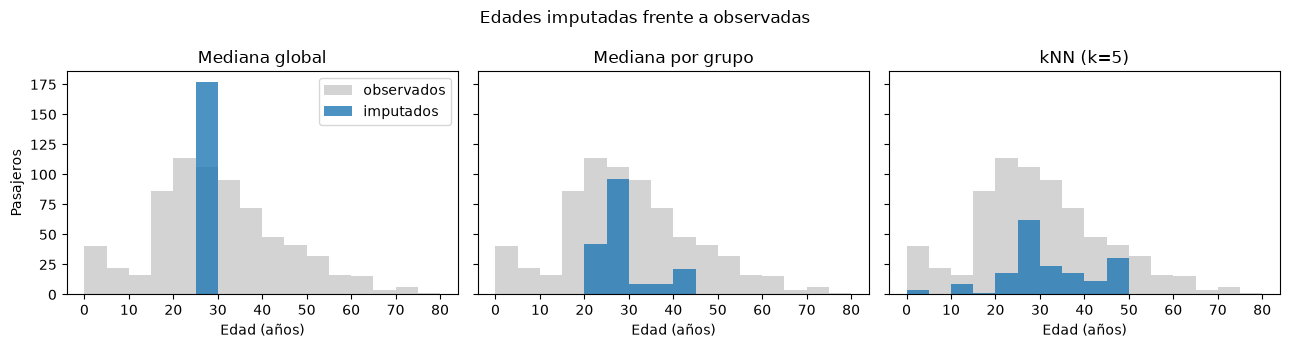

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
bins = np.arange(0, 85, 5)
imputados = edad_orig.isna()

for ax, (nombre, serie) in zip(axes, [("Mediana global", edad_mediana),
                                       ("Mediana por grupo", edad_grupo),
                                       ("kNN (k=5)", edad_knn)]):
    ax.hist(edad_orig.dropna(), bins=bins, color="lightgray", label="observados")
    ax.hist(serie[imputados], bins=bins, color="tab:blue", alpha=0.8, label="imputados")
    ax.set_title(nombre)
    ax.set_xlabel("Edad (años)")
axes[0].set_ylabel("Pasajeros")
axes[0].legend()
fig.suptitle("Edades imputadas frente a observadas")
plt.tight_layout()
plt.show()

- La **mediana global** coloca los 177 valores en una sola barra (28 años). Crea un pico artificial y reduce la desviación típica.
- La **mediana por grupo** reparte los valores en varias edades según clase y sexo. Es algo más realista, pero sigue concentrándolos en unos pocos valores.
- **kNN** produce valores variados y conserva mejor la forma y la dispersión de la distribución, a cambio de más cálculo y de depender del escalado y de $k$.

Nos quedamos con la imputación por kNN:

In [20]:
df_imp["age"] = edad_knn.round(1)
df_imp.isna().sum().sum()

np.int64(0)

### 3.10. Valores atípicos

El diagrama de caja muestra de un vistazo la asimetría y los candidatos a atípico:

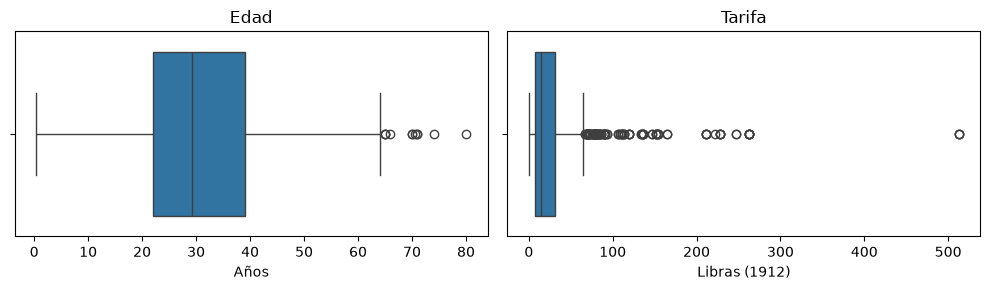

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.boxplot(x=df_imp["age"], ax=axes[0])
axes[0].set_title("Edad")
axes[0].set_xlabel("Años")
sns.boxplot(x=df_imp["fare"], ax=axes[1])
axes[1].set_title("Tarifa")
axes[1].set_xlabel("Libras (1912)")
plt.tight_layout()
plt.show()

In [22]:
def limites_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    ric = q3 - q1
    return q1 - k * ric, q3 + k * ric

fare = df_imp["fare"]
inf, sup = limites_iqr(fare)
atip_iqr = (fare < inf) | (fare > sup)
atip_z = ((fare - fare.mean()) / fare.std()).abs() > 3

print(f"Límites IQR: [{inf:.1f}, {sup:.1f}]")
print(f"Atípicos por IQR:     {atip_iqr.sum()} ({atip_iqr.mean():.0%})")
print(f"Atípicos por z-score: {atip_z.sum()} ({atip_z.mean():.0%})")
df_imp.loc[atip_iqr, "pclass"].value_counts()

Límites IQR: [-26.7, 65.6]
Atípicos por IQR:     116 (13%)
Atípicos por z-score: 20 (2%)


pclass
1    104
3      7
2      5
Name: count, dtype: int64

El IQR marca como atípico el ~13 % de las tarifas, y casi todas son de **1.ª clase**. No son errores: son billetes caros legítimos en una variable muy asimétrica. Borrarlas eliminaría a buena parte de la 1.ª clase y sesgaría cualquier análisis de supervivencia.

En lugar de borrar, lo prudente es **marcar**. Así se conservan los datos y cada análisis posterior puede decidir si excluirlos, transformarlos (por ejemplo con $\log(1 + x)$, ver [transformación de datos](03-transformacion-datos.ipynb)) o usar métodos robustos:

In [23]:
df_imp["fare_atipica"] = atip_iqr

# Resultado final: sin perdidos y con los atípicos identificados
print(df_imp.shape)
df_imp.head()

(891, 13)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone,fare_atipica
0,0,3,male,22.0,1,0,7.2500,S,man,True,Desconocida,False,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,False,True
2,1,3,female,26.0,0,0,7.9250,S,woman,False,Desconocida,True,False
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,Desconocida,True,False


## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Función / clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `pd.read_csv` | `sep`, `decimal` | Separador de campos y decimal | Los CSV en formato español usan `sep=";"` y `decimal=","` |
| | `na_values` | Qué textos se leen como `NaN` | Añade los centinelas conocidos: `na_values=["n/d", "-", 999]` |
| | `encoding` | Codificación de caracteres | Si aparecen `Ã©` en lugar de `é`, prueba `"latin-1"` en vez de `"utf-8"` |
| `pd.to_numeric` | `errors` | Qué hacer con lo que no es número | `"coerce"` convierte en `NaN` **sin avisar**: revisa antes qué valores se pierden |
| `DataFrame.merge` | `how` | Qué filas se conservan | `"inner"` (por defecto) descarta las que no cruzan; usa `"left"` para no perder registros |
| | `validate` | Cardinalidad esperada de la clave | `"m:1"` o `"1:1"`: da error si la clave de la derecha está repetida |
| | `indicator` | Columna `_merge` con el origen de cada fila | Permite contar las filas que no han cruzado |
| `DataFrame.pivot` / `pivot_table` | `index`, `columns`, `values`, `aggfunc` | Paso de formato largo a ancho | `pivot` falla con duplicados; `pivot_table` los agrega (media por defecto) sin avisar |
| `DataFrame.melt` | `id_vars`, `var_name`, `value_name` | Paso de formato ancho a largo | Útil para graficar varias variables con seaborn |
| `SimpleImputer` | `strategy` | `mean`, `median`, `most_frequent`, `constant` | `median` para numéricas asimétricas; `most_frequent` o `constant` para categóricas |
| | `add_indicator` | Añade columnas que marcan qué valores se imputaron | Útil cuando que falte un dato es informativo en sí mismo (MAR/MNAR) |
| `KNNImputer` | `n_neighbors` | Cuántos vecinos se promedian | 5 por defecto. Con $k$ pequeño es ruidoso, con $k$ grande tiende a la media |
| | `weights` | `uniform` o `distance` | `distance` da más peso a los vecinos más cercanos |
| Regla IQR | factor $k$ | Anchura de los bigotes | 1,5 es el estándar; 3 detecta solo los "extremos" |
| z-score | umbral | Distancia en desviaciones típicas | 3 es lo habitual; solo tiene sentido con distribuciones aproximadamente normales |

### 4.2. Errores comunes

Estas lecciones salen de trabajar con datos reales: un análisis de accidentes de tráfico urbano (dos ficheros anuales, un callejero y datos meteorológicos diarios).

**1. El `merge` interno pierde filas sin avisar.** Al cruzar los accidentes con los datos meteorológicos por fecha, el `merge` interno eliminó en silencio **2.689 accidentes (≈18 %)**, porque la serie meteorológica empezaba en mayo del primer año. El cruce con el callejero eliminó otros 99 cuyo código de calle no existía. Ninguno de los dos dio error. **Comprueba siempre el número de filas antes y después** de cada `merge`, o usa `how="left"` con `indicator=True` (ver [3.3](#3.3.-Enriquecimiento)).

**2. `fillna(0)` sobre todo el DataFrame.** Para las columnas de víctimas (fallecidos, heridos graves, heridos leves), un vacío significaba "ninguno", y el `0` era correcto. Pero el mismo `fillna(0)` aplicado a todo el DataFrame puso a `0` la racha de viento. **Una racha de 0 m/s no existe** en esos datos (la mínima observada era 3,6 m/s): el valor imputado es imposible y además se convierte en un atípico artificial. La imputación se decide **columna a columna**:

In [24]:
victimas = pd.DataFrame({
    "fallecidos": [np.nan, 1, np.nan, np.nan],
    "racha_ms": [8.9, np.nan, 12.1, 6.4],
})

mal = victimas.fillna(0)
bien = victimas.fillna({
    "fallecidos": 0,                             # vacío estructural: 0 es la verdad
    "racha_ms": victimas["racha_ms"].median(),  # perdido: se estima
})
pd.concat({"fillna(0)": mal, "por columna": bien}, axis=1)

fillna(0)          por columna         
  fallecidos racha_ms  fallecidos racha_ms
0        0.0      8.9         0.0      8.9
1        1.0      0.0         1.0      8.9
2        0.0     12.1         0.0     12.1
3        0.0      6.4         0.0      6.4

**3. Imputar antes de dividir en entrenamiento y prueba (fuga de datos).** Si la mediana, la media o los vecinos del kNN se calculan con **todos** los datos, el conjunto de prueba "filtra" información al entrenamiento y la evaluación sale optimista. El imputador, como cualquier transformación, se **ajusta solo con el entrenamiento** (`fit`) y después se **aplica** a ambos conjuntos (`transform`). Dentro de un `Pipeline` de scikit-learn esto ocurre automáticamente.

In [25]:
X = df[["age", "fare"]]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

imputador = SimpleImputer(strategy="median").fit(X_train)   # solo train
X_train_imp = imputador.transform(X_train)
X_test_imp = imputador.transform(X_test)                    # misma mediana que en train

print(f"Mediana de 'age' aprendida en train: {imputador.statistics_[0]:.1f}")
print(f"Mediana de 'age' con todos los datos: {X['age'].median():.1f}")

Mediana de 'age' aprendida en train: 28.0
Mediana de 'age' con todos los datos: 28.0


Aquí ambas medianas coinciden (28 años), porque la mediana es robusta y hay muchos datos. Pero el principio no cambia: con estadísticos menos estables (media, kNN, modelos), con pocos datos o con transformaciones encadenadas, la diferencia puede ser grande y difícil de detectar. Más detalles en [flujo de ML y evaluación](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb).

**4. Borrar atípicos que son datos legítimos.** Aplicar el filtro IQR en cadena a varias columnas (latitud, longitud, velocidad del viento…) va sumando las filas eliminadas en cada paso, y en coordenadas geográficas "atípico" solo significa "lejos del centro". En la tarifa del Titanic, el IQR habría eliminado casi toda la 1.ª clase ([3.10](#3.10.-Valores-atípicos)). Antes de borrar, pregúntate **qué causa** el valor. Si no es un error, márcalo, transfórmalo o usa métodos robustos.

**5. `errors="coerce"` esconde problemas.** Convierte en `NaN` todo lo que no entiende: separadores de miles, unidades, códigos como `"Ip"` (precipitación inapreciable, que en realidad es ≈ 0) o `"n/d"`. Revisa siempre qué valores originales se han perdido ([3.2](#3.2.-Tipos-de-variable)) y trata cada código según su significado.

**6. Comprobar duplicados solo con la fila completa.** `duplicated()` no detecta un identificador repetido cuando el resto de columnas cambia. En el análisis de accidentes, 3 expedientes aparecían dos veces con datos distintos. Para ver ese caso, comprueba la **clave**: `df["id"].duplicated()`.

**7. Recorrer filas con bucles.** Construir fechas fila a fila con un bucle `for` e `iloc`/`loc` es lento y propenso a errores. `pd.to_datetime` acepta directamente las columnas de año, mes, día y hora:

In [26]:
partes = pd.DataFrame({"year": [2023, 2024], "month": [6, 2], "day": [2, 14], "hour": [18, 7]})
pd.to_datetime(partes)  # vectorizado, sin bucles

0   2023-06-02 18:00:00
1   2024-02-14 07:00:00
dtype: datetime64[us]

## 5. Comparación con métodos relacionados

### 5.1. Estrategias para valores perdidos

| Estrategia | Cómo funciona | Cuándo usarla | Riesgo / sesgo |
|---|---|---|---|
| **Eliminar filas** (`dropna`) | Descarta los registros incompletos | Pocos perdidos (< 5 %) y MCAR | Pierde información. Si no es MCAR, sesga la muestra |
| **Eliminar la columna** | Descarta la variable | Casi todo perdido y sin valor informativo | Se pierde la variable entera |
| **Constante / categoría propia** | `0`, `"Desconocida"` | Vacío estructural (el `0` es la verdad) o ausencia informativa | Un valor constante en numéricas crea un pico artificial |
| **Media / mediana / moda** | Un único valor para todos | Pocos perdidos, MCAR, primera aproximación | Reduce la varianza y debilita las correlaciones |
| **Por grupo** (`groupby().transform`) | Mediana o moda dentro de cada grupo | MAR respecto a variables categóricas conocidas | Grupos pequeños dan estimaciones inestables |
| **kNN** (`KNNImputer`) | Media de los $k$ registros más parecidos | MAR, relaciones no lineales, varias variables | Necesita escalar; es lento con muchos datos; depende de $k$ |
| **Iterativa / por modelo** (`IterativeImputer`, missForest) | Predice cada variable a partir de las demás | MAR, muchas variables relacionadas | Más complejo; puede sobreajustar; en scikit-learn aún es experimental |

En todos los casos se puede añadir un **indicador de imputación** (`add_indicator=True`) para que el modelo sepa qué valores eran originales.

### 5.2. Métodos de detección de atípicos

| Método | Tipo | Supuestos | Ventajas | Limitaciones |
|---|---|---|---|---|
| **IQR / boxplot** | Univariante | Ninguno | Robusto, fácil de visualizar | Marca toda la cola de las variables asimétricas |
| **z-score** ($\lvert z\rvert > 3$) | Univariante | Normalidad aproximada | Sencillo e interpretable | La media y la σ se contaminan con los propios atípicos |
| **z-score robusto** (mediana y DAM) | Univariante | Simetría aproximada | No se deja arrastrar por los atípicos | Sigue siendo univariante |
| **Mahalanobis** | Multivariante | Normalidad multivariante aproximada | Detecta combinaciones raras de valores | La covarianza también se contamina; alternativa robusta: `MinCovDet` |
| **Basados en modelos** (Isolation Forest, LOF) | Multivariante | Ninguno fuerte | Formas complejas, muchas dimensiones | Hiperparámetros difíciles de fijar y menos interpretables. Se verán en detección de anomalías |

**Regla práctica:** empieza por lo univariante (boxplot e IQR) para entender cada variable, usa Mahalanobis o un modelo cuando importen las combinaciones, y **decide el tratamiento según la causa**, no según el método que lo ha detectado.

## 6. Referencias

### Fuentes

- pandas: [*Working with missing data*](https://pandas.pydata.org/docs/user_guide/missing_data.html) y [*Merge, join, concatenate and compare*](https://pandas.pydata.org/docs/user_guide/merging.html).
- scikit-learn: [*Imputation of missing values*](https://scikit-learn.org/stable/modules/impute.html).
- seaborn: [`seaborn.load_dataset`](https://seaborn.pydata.org/generated/seaborn.load_dataset.html).
- Dataset: [`titanic.csv` en seaborn-data](https://github.com/mwaskom/seaborn-data), versión adaptada de los datos de la competición [*Titanic* de Kaggle](https://www.kaggle.com/c/titanic/data).

### Para saber más

- Little, R. J. A. y Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3.ª ed.). Wiley. La referencia clásica sobre valores perdidos: mecanismos MCAR / MAR / MNAR e imputación.
- Osborne, J. W. (2013). *Best Practices in Data Cleaning*. SAGE. Guía práctica de todo el proceso de limpieza: valores perdidos, atípicos y transformaciones.